# Climate Statistics Pipeline — ERA5 + IFS over Illinois

Three-module pipeline:

1. **Acquire** — download ERA5 + IFS raw data (with local caching)
2. **Process** — compute metrics, statistics, aggregate to counties/ZIP codes, save CSVs
3. **Visualize** — load CSVs and plot time series + maps for every metric

Edit the **Parameters** cell below to configure metrics, time range, and thresholds.

In [1]:
import os

# ═══ PARAMETERS ════════════════════════════════════════════════════════════
# ── Data directory ────────────────────────────────────────────────────────
DATA_DIR = "data"

# ── Time range (inclusive) ────────────────────────────────────────────────
YEAR_START = 2020
YEAR_END   = 2026

# ── IFS forecast ─────────────────────────────────────────────────────────
FORECAST_DAYS = 14  # 0 = gap-fill only, 7 = 1-week deterministic forecast

# ── Metrics to compute (any subset of the registry) ──────────────────────
METRICS = [
    "heat_index",
    "wet_bulb_temperature",
    "apparent_temperature",
    "humidex",
    "normal_effective_temperature",
    "wind_chill",
    "wbgt",
    "2m_temperature",
]

# ── Thresholds for exceedance statistics ──────────────────────────────────
THRESHOLDS = {
    "heat_index":                   {"above": [90, 104]},
    "wet_bulb_temperature":         {"above": [75, 80]},
    "apparent_temperature":         {"above": [90, 105]},
    "humidex":                      {"above": [90, 104]},
    "normal_effective_temperature": {"above": [70, 80]},
    "wind_chill":                   {"below": [-25, -15, 0, 32]},
    "wbgt":                         {"above": [80, 85]},
    "2m_temperature":               {"above": [95, 100], "below": [0, 32]},
}

# ── Unit conversion ───────────────────────────────────────────────────────
CONVERT_TO_F = True

# ── Visualization ─────────────────────────────────────────────────────────
EXAMPLE_COUNTY  = "Cook County"
EXAMPLE_ZIPCODE = "61801"

# Which metric to visualize (must be in METRICS above):
PLOT_METRIC = "wind_chill"

# Which daily column to plot in time series:
#   "daily_max", "daily_mean", "daily_min",
#   "hours_above_{t}" (e.g. "hours_above_90"), "hours_below_{t}"
TIMESERIES_SUMMARY = "hours_below_0"

# Which averages column to plot on maps:
#   "avg_daily_max", "avg_daily_mean", "avg_daily_min",
#   "avg_days_per_year_above_{t}", "avg_hours_per_year_above_{t}",
#   "avg_days_per_year_below_{t}", "avg_hours_per_year_below_{t}"
MAP_SUMMARY = "avg_hours_per_year_below_0"

# ── Derived paths ─────────────────────────────────────────────────────────
CACHE_DIR           = os.path.join(DATA_DIR, "cache")
OUTPUT_DIR          = os.path.join(DATA_DIR, "output")
SHAPEFILE_PATH      = os.path.join(DATA_DIR, "shapefiles", "county", "tl_2025_us_county.shp")
ZCTA_SHAPEFILE_PATH = os.path.join(DATA_DIR, "shapefiles", "zipcodes", "tl_2025_us_zcta520.shp")

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
from climstat.data_acquisition import acquire_data
from climstat.data_process import process_data
from climstat.data_visualization import visualize_data

---
### Module 1 — Acquire raw data (ERA5 + IFS)

In [3]:
raw = acquire_data(
    metrics=METRICS,
    year_start=YEAR_START,
    year_end=YEAR_END,
    cache_dir=CACHE_DIR,
    forecast_days=FORECAST_DAYS,
)

ERA5 variables needed: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_dewpoint_temperature', '2m_temperature']
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20200101_20201231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20210101_20211231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20220101_20221231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20230101_20231231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20240101_20241231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20250101_20251231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20260101_20260326.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20200101_20201231.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20210101_20211231.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20220101_20221231.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20230101_20231231.nc
[era5_extract] Cache hit: era5_10m_v_comp

---
### Module 2 — Process: metrics, statistics, aggregation, CSV export

In [4]:
result = process_data(
    era5_ds=raw["era5_ds"],
    ifs_ds=raw["ifs_ds"],
    metrics=METRICS,
    thresholds=THRESHOLDS,
    shapefile_path=SHAPEFILE_PATH,
    zcta_shapefile_path=ZCTA_SHAPEFILE_PATH,
    output_dir=OUTPUT_DIR,
    convert_to_f=CONVERT_TO_F,
)

  ERA5 data range: 20200101 -> 20260320
  ERA5 cached (skipping): heat_index, wet_bulb_temperature, apparent_temperature, humidex, normal_effective_temperature, wind_chill, wbgt, 2m_temperature

All metrics cached — skipping computation.
[zipcode_agg] Loading Illinois ZCTAs ...
[zipcode_agg] 1396 ZCTAs intersecting Illinois
[zipcode_agg] Assigning ZCTAs to nearest grid points ...
[zipcode_agg] 1396 ZCTAs mapped to 274 unique grid points
  IFS data range: 20260321 -> 20260411
  IFS cached (skipping): heat_index, wet_bulb_temperature, apparent_temperature, humidex, normal_effective_temperature, wind_chill, wbgt, 2m_temperature

All IFS metrics cached — skipping computation.


/Users/cristi/Desktop/claude/climstat-era5/climstat/data_process/shapefiles.py:112: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = zctas.geometry.centroid
/Users/cristi/Desktop/claude/climstat-era5/climstat/data_process/zipcode_agg.py:88: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = zctas.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


---
### Module 3 — Visualize

/Users/cristi/Desktop/claude/climstat-era5/climstat/data_process/shapefiles.py:112: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = zctas.geometry.centroid



Visualizing: wind_chill

Visualization complete for 1 metrics.


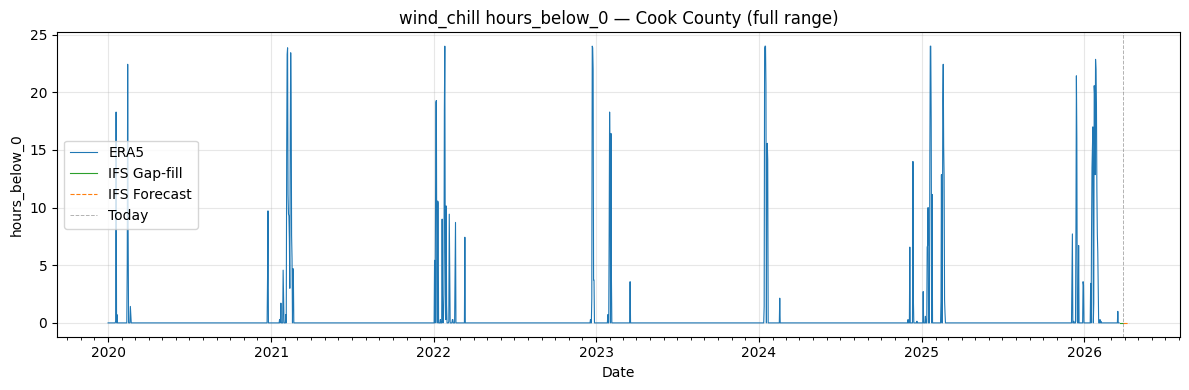

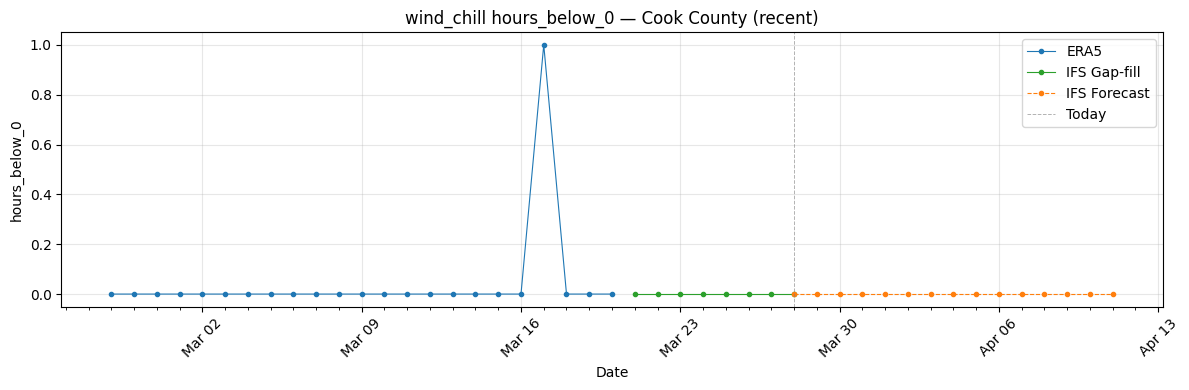

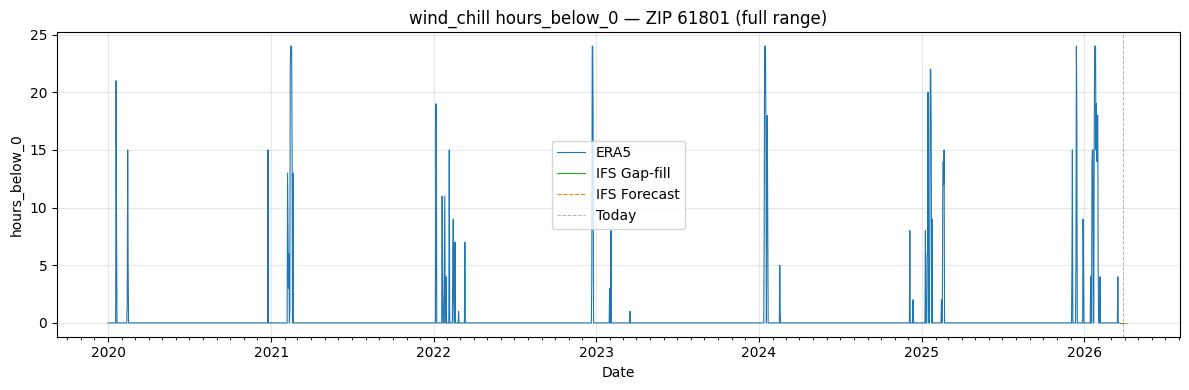

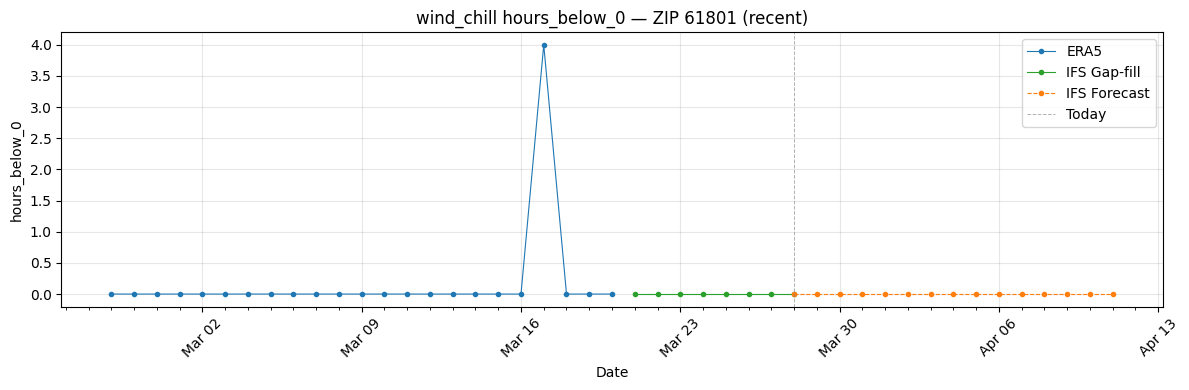

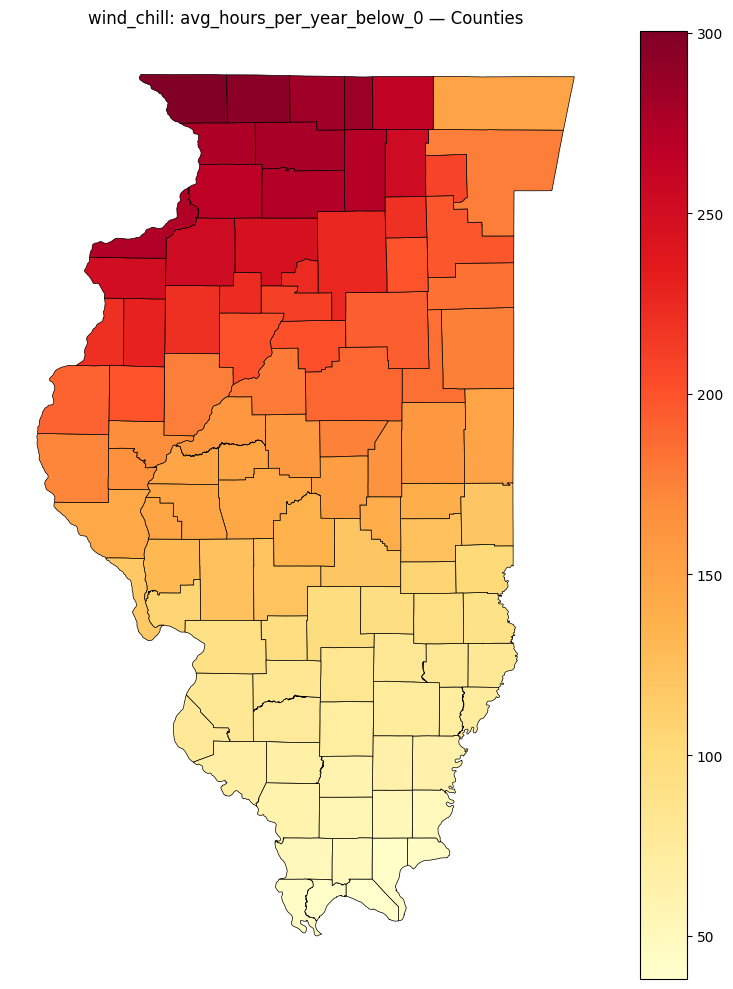

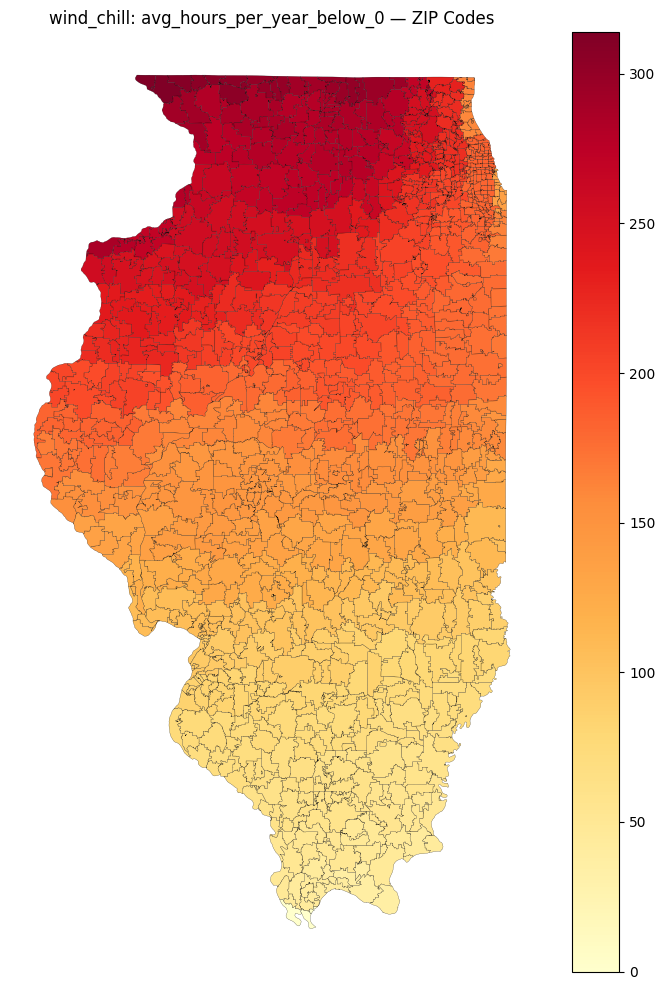

In [5]:
visualize_data(
    metrics=[PLOT_METRIC],
    thresholds=THRESHOLDS,
    output_dir=OUTPUT_DIR,
    era5_start=result["era5_start"],
    era5_end=result["era5_end"],
    ifs_start=result["ifs_start"],
    ifs_end=result["ifs_end"],
    shapefile_path=SHAPEFILE_PATH,
    zcta_shapefile_path=ZCTA_SHAPEFILE_PATH,
    example_county=EXAMPLE_COUNTY,
    example_zipcode=EXAMPLE_ZIPCODE,
    timeseries_summary=TIMESERIES_SUMMARY,
    map_summary=MAP_SUMMARY,
)